Calcoliamo la media delle lampade di calibrazione dello strumento Catherine trovate nell'archivio ESO

E' una lamp wave di Catherine ma binnata $1\times1$ anzichè $2\times1$ come vorrei io e non misura $2106\times2000$ come vorrei io.\
Ma è una lampada al ThAr? Perchè ho l'ashi della vista del braccio VIS di XSHOOTER.

In [4]:
import glob
import os
from pyraf import iraf

# 0. If you Windows operative system, be sure that in your input file_list.txt there is _ and not :
# also replace the middle point "·" with "_" on the files automatically dowloaded by the ESO archive into C or D Windows hard disks.

# 1. Load the necessary IRAF packages
iraf.noao()
iraf.imred()
iraf.ccdred()

# 2. Make sure to adjust the pattern to match your actual lamp file names
lamp_pattern = "XSHOO*.fits"
lamp_files = sorted(glob.glob(lamp_pattern))

if not lamp_files:
    raise FileNotFoundError(f"No files found with pattern: {lamp_pattern}")

# If the data comes from MEF (multi-extension) instruments like X-Shooter,
# specify the scientific extension for each file (e.g., bias.fits[1])
# bias_files = [f"{f}[1]" for f in bias_files]

input_list = "lamp_list_forWindows.txt"
with open(input_list, "w") as f:   #it's writing file names into the list automatically 
    for filename in lamp_files:
        f.write(f"{filename}\n")

# 3. Name of the output Master lamp file
output_master_lamp = "lamp.fits"

# Remove the previous output if it already exists
if os.path.exists(output_master_lamp):
    os.remove(output_master_lamp)

# 4. Run zerocombine using PyRAF
# Note: combine='median' or 'average' with reject='sigclip' or 'minmax'
iraf.zerocombine(
    input=f"@{input_list}",
    output=output_master_lamp,
    combine="average",
    reject="minmax",
    ccdtype="",   # Leave it empty to avoid filtering on ccdtype header, the default is "zero" but this fits header has different keywords
    process="no",  # Do not process the output (e.g., do not trim or scale)
    scale="none",  # Bias frames typically do not require scaling
    statsec="",  # Use the entire frame if empty
    #interactive="no",
)

print(f"Master lamp created successfully: {output_master_lamp}")

# 5. Cleanup (optional)
#if os.path.exists(input_list):
#    os.remove(input_list)

Master lamp created successfully: lamp.fits


Adesso dovrei dividere la lamp.fits con la task apall e identitificare le righe con la lista ashi con la task echelle identify.\
Dovrei tagliare la lamp in 14 fenditure come la stella ma le dimensioni della CCD e il binning non combaciano.

Filename: lamp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2106, 4000)   float32   
Dati 2D trovati nell'HDU [0] (PRIMARY)
Range pixel effettivo: [1000.3, 65535.0]
Range visualizzato (1%-99%): [1010.0, 3908.7]


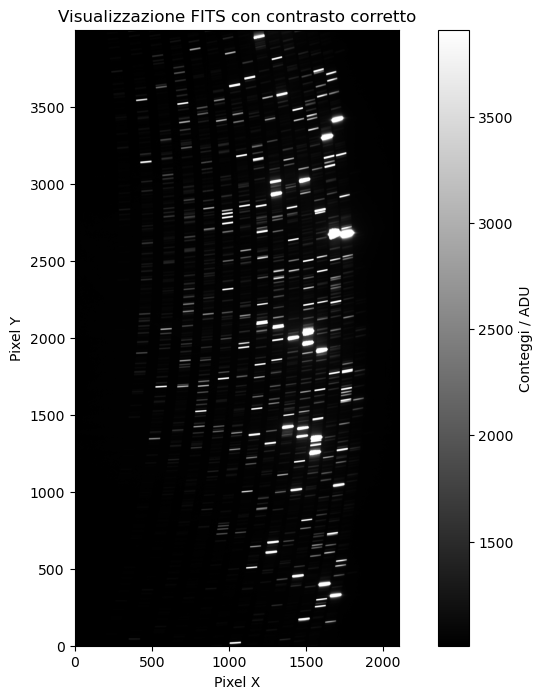

In [7]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

file_path = "lamp.fits"

with fits.open(file_path) as hdul:
    hdul.info()  # Verifica quale HDU contiene ImageHDU o PrimaryHDU con dati

    # 1. Trova la prima estensione valida contenente un array 2D
    data = None
    for i, hdu in enumerate(hdul):
        if hdu.data is not None and getattr(hdu.data, "ndim", 0) == 2:
            data = hdu.data
            print(f"Dati 2D trovati nell'HDU [{i}] ({hdu.name})")
            break

if data is not None:
    # 2. Rimuovi eventuali NaN o infiniti per il calcolo del contrasto
    valid_data = data[np.isfinite(data)]

    # 3. Calcola i limiti di visualizzazione escludendo gli estremi (es. 1% e 99%)
    vmin, vmax = np.percentile(valid_data, [1.0, 99.0])

    print(
        f"Range pixel effettivo: [{np.min(valid_data):.1f}, {np.max(valid_data):.1f}]"
    )
    print(f"Range visualizzato (1%-99%): [{vmin:.1f}, {vmax:.1f}]")

    # 4. Mostra l'immagine con scala di grigi o viridis
    plt.figure(figsize=(10, 8))
    plt.imshow(data, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    plt.colorbar(label="Conteggi / ADU")
    plt.title("Visualizzazione FITS con contrasto corretto")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.show()
else:
    print("Nessun array di dati 2D trovato nel file FITS.")

In [ ]:
#header of the lamp.fits
from astropy.io import fits

# Apri il file FITS
filename = "lamp.fits"
with fits.open(filename) as hdul:
    # Mostra la struttura del file (opzionale)
    hdul.info() 
    
    # Estrai l'header dell'estensione primaria (HDU 0)
    header = hdul[0].header 

# Stampa l'header in modo leggibile ed elegante
print(repr(header))

Filename: lamp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2106, 4000)   float32   
SIMPLE  =                    T / Fits standard                                  
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                 2106 / Axis length                                    
NAXIS2  =                 4000 / Axis length                                    
EXTEND  =                    T / File may contain extensions                    
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
IRAF-TLM= '2026-09-16T17:41:47' / Time of last modification                     
DATE    = '2026-09-16T17:41:49' / UT date when this file was written            
TELESCOP= 'Tel name not set'            / ESO Telescope Name                    
INSTRUME= 'XSHOOTER'                    

In [1]:
import os
from pyraf import iraf

def rebin_xshooter_vis_lamp(input_fits, output_fits):
    # Carica il package IRAF necessario
    iraf.images(_doprint=0)

    # Rimuove il file di output se già presente
    if os.path.exists(output_fits):
        os.remove(output_fits)

    print(f"1. Compressione 1x2 con blkavg: {input_fits} -> {output_fits}")
    
    # b1=1 (invariato in X), b2=2 (somma su Y a blocchi di 2)
    # option='sum' conserva il numero di conteggi totali della lampada
    iraf.blkavg(
        input=input_fits,
        output=output_fits,
        b1=1,
        b2=2,
        option="sum"
    )

    print("2. Aggiornamento dell'header per congruenza ESO...")

    # Mappa delle keyword da modificare o aggiungere nel nuovo file FITS
    header_updates = {
        # Fattori di binning
        "CDELT2": 2.0,
        "HIERARCH ESO DET WIN1 BINY": 2,
        
        # Dimensioni dell'asse Y ricalcolate
        "HIERARCH ESO DET WIN1 NY": 2000,
        "HIERARCH ESO DET OUT1 NY": 2000,
        
        # Se presenti nel sistema o usate da tool esterni:
        "BINY": 2
    }

    for key, val in header_updates.items():
        try:
            iraf.hedit(
                images=output_fits,
                fields=key,
                value=val,
                add=True,       # Aggiunge la chiave se mancava, la sovrascrive se esiste
                addonly=False,
                delete=False,
                verify=False,
                show=False,
                update=True
            )
        except Exception as e:
            print(f"Avviso su {key}: {e}")

    print(f"Fatto. Nuovo file {output_fits} pronto per la pipeline.")

if __name__ == "__main__":
    # Inserisci i nomi dei tuoi file
    file_sorgente = "lamp.fits"
    file_destinazione = "lamp_binned.fits"

    rebin_xshooter_vis_lamp(file_sorgente, file_destinazione)

1. Compressione 1x2 con blkavg: lamp.fits -> lamp_binned.fits
2. Aggiornamento dell'header per congruenza ESO...
Fatto. Nuovo file lamp_binned.fits pronto per la pipeline.


Filename: lamp_binned.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2106, 2000)   float32   
Dati 2D trovati nell'HDU [0] (PRIMARY)
Range pixel effettivo: [2006.3, 130072.0]
Range visualizzato (1%-99%): [2020.0, 7944.3]


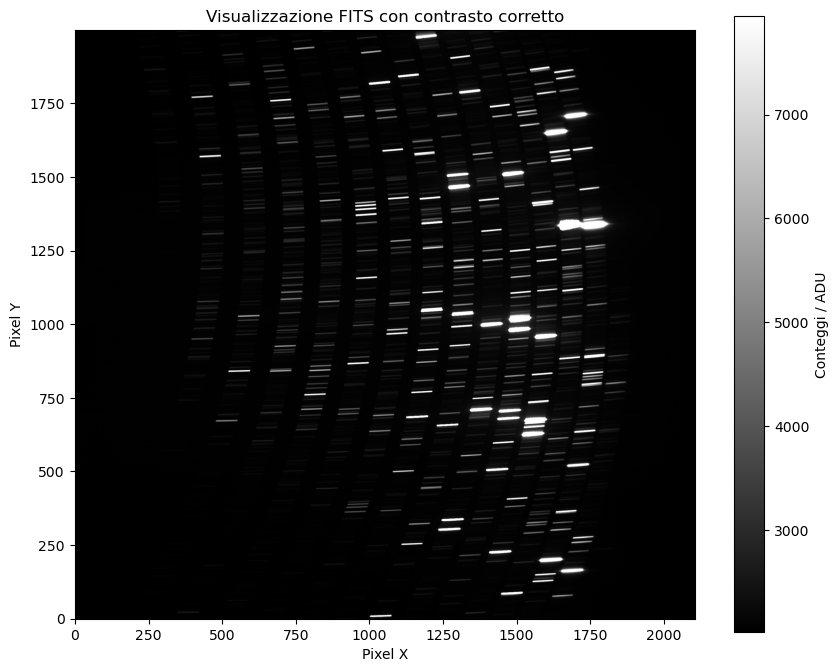

In [3]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

file_path = "lamp_binned.fits"

with fits.open(file_path) as hdul:
    hdul.info()  # Verifica quale HDU contiene ImageHDU o PrimaryHDU con dati

    # 1. Trova la prima estensione valida contenente un array 2D
    data = None
    for i, hdu in enumerate(hdul):
        if hdu.data is not None and getattr(hdu.data, "ndim", 0) == 2:
            data = hdu.data
            print(f"Dati 2D trovati nell'HDU [{i}] ({hdu.name})")
            break

if data is not None:
    # 2. Rimuovi eventuali NaN o infiniti per il calcolo del contrasto
    valid_data = data[np.isfinite(data)]

    # 3. Calcola i limiti di visualizzazione escludendo gli estremi (es. 1% e 99%)
    vmin, vmax = np.percentile(valid_data, [1.0, 99.0])

    print(
        f"Range pixel effettivo: [{np.min(valid_data):.1f}, {np.max(valid_data):.1f}]"
    )
    print(f"Range visualizzato (1%-99%): [{vmin:.1f}, {vmax:.1f}]")

    # 4. Mostra l'immagine con scala di grigi o viridis
    plt.figure(figsize=(10, 8))
    plt.imshow(data, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    plt.colorbar(label="Conteggi / ADU")
    plt.title("Visualizzazione FITS con contrasto corretto")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.show()
else:
    print("Nessun array di dati 2D trovato nel file FITS.")

In [4]:
#header of the lamp_binned.fits
from astropy.io import fits

# Apri il file FITS
filename = "lamp.fits"
with fits.open(filename) as hdul:
    # Mostra la struttura del file (opzionale)
    hdul.info() 
    
    # Estrai l'header dell'estensione primaria (HDU 0)
    header = hdul[0].header 

# Stampa l'header in modo leggibile ed elegante
print(repr(header))

Filename: lamp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2106, 4000)   float32   
SIMPLE  =                    T / Fits standard                                  
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                 2106 / Axis length                                    
NAXIS2  =                 4000 / Axis length                                    
EXTEND  =                    T / File may contain extensions                    
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
IRAF-TLM= '2026-09-16T17:41:47' / Time of last modification                     
DATE    = '2026-09-16T17:41:49' / UT date when this file was written            
TELESCOP= 'Tel name not set'            / ESO Telescope Name                    
INSTRUME= 'XSHOOTER'                    

 [astropy.io.fits.verify]


In [6]:
import os
from pyraf import iraf

# 1. Load packages containing imarith and statistics
iraf.images()
iraf.imutil()

# 2.0 Define relative paths
bias_dir = os.path.join("..", "bias")

# 2.1 Define file names
lamp_raw = "lamp_binned.fits"
master_bias = os.path.join(bias_dir, "Bias.fits")

# Intermediate and final files
lamp_sub_bias = "lamp_binned_sub_bias.fits"


def remove_if_exists(filepath):
    if os.path.exists(filepath):
        os.remove(filepath)


for f in [lamp_sub_bias]:
    remove_if_exists(f)

#you have to use APSUM before other things.

# 3. Step 1: Subtraction of Bias from the Flat (Flat - Bias)
iraf.imarith(
    operand1=lamp_raw,
    op="-",
    operand2=master_bias,
    result=lamp_sub_bias,
    title="Lamp binned debiased",
)


C'è qualche problemino ad identificare le 14 aperture.